# Градиентный бустинг (HistGradientBoosting)

Сравниваем с бейзлайном из `02_logreg_baseline`, та же задача и то же разбиение (seed=42).

In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = "png"
plt.rcParams["figure.dpi"] = 72
from sklearn.pipeline import make_pipeline
from ml_toolkit.data import make_split
from ml_toolkit.features import make_preprocessor
from ml_toolkit.models import build_model
from ml_toolkit.metrics import calc_metrics
from ml_toolkit.viz import plot_param_curve

In [2]:
split = make_split("breast_cancer", seed=42)

## Подбор learning rate

In [3]:
rows = []
for lr in [0.01, 0.03, 0.05, 0.1, 0.3]:
    clf = make_pipeline(make_preprocessor(), build_model(
        "hist_gb", learning_rate=lr, max_iter=300, max_leaf_nodes=15, l2_regularization=1.0, random_state=42))
    clf.fit(split.X_train, split.y_train)
    m = calc_metrics(split.y_val, clf.predict(split.X_val), clf.predict_proba(split.X_val))
    rows.append({"learning_rate": lr, **m})
lr_table = pd.DataFrame(rows).round(4)
lr_table

,learning_rate,accuracy,f1,roc_auc
0,0.01,0.9386,0.9343,0.9892
1,0.03,0.9561,0.9531,0.9908
2,0.05,0.9561,0.9531,0.9925
3,0.10,0.9561,0.9531,0.9921
4,0.30,0.9649,0.9627,0.9928


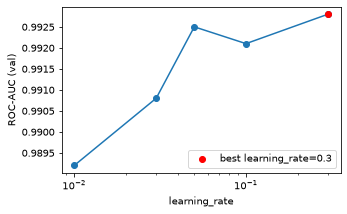

In [4]:
plot_param_curve(lr_table.learning_rate.tolist(), lr_table.roc_auc.tolist(), "learning_rate", "ROC-AUC (val)")
plt.show()

## Финальная модель

Берём learning rate с лучшим ROC-AUC на валидации и оцениваем на тесте один раз.

In [5]:
best_lr = float(lr_table.sort_values(["roc_auc", "f1"], ascending=False).iloc[0].learning_rate)
final = make_pipeline(make_preprocessor(), build_model(
    "hist_gb", learning_rate=best_lr, max_iter=300, max_leaf_nodes=15, l2_regularization=1.0, random_state=42))
final.fit(split.X_train, split.y_train)
test_metrics = calc_metrics(split.y_test, final.predict(split.X_test), final.predict_proba(split.X_test))
print(f"best learning_rate = {best_lr}")
print("TEST:", {k: round(v, 4) for k, v in test_metrics.items()})

best learning_rate = 0.3
TEST: {'accuracy': 0.9298, 'f1': 0.9246, 'roc_auc': 0.9904}
